# Project Overview: Countries Life Expectancies

# 1.1 Introduction
### Life expectancy serves as a primary indicator of global population health, socio-economic development, and healthcare system efficacy. While prior studies heavily emphasize basic demographic variables and mortality rates, comprehensive multi-variable evaluations examining the direct impact of preventative immunization coverage, national health expenditures, and educational attainment remain scarce. This project analyzes a comprehensive global dataset encompassing 193 countries across multiple years to model and evaluate the primary factors influencing human longevity.

# 1.2 Problem Statement
### Global health disparities persist across nations, yet governments and public health policymakers frequently lack granular, data-driven insights regarding which targeted interventions yield the highest impact on life expectancy. Traditional analytical approaches often isolate demographic metrics while neglecting the complex, multi-faceted interactions between preventative healthcare measures (such as Hepatitis B, Polio, and Diphtheria immunizations), disease prevalence (including HIV/AIDS and measles), and economic-educational inputs (such as GDP, total health expenditure, schooling, and income composition). Consequently, optimizing resource allocation for maximum health benefit remains a critical challenge.

# 1.3 Purpose of the Project

### Identify Significant Predictors: Isolate and evaluate the most influential socio-economic, medical, and educational drivers affecting global life expectancy variations.

### Develop Predictive Pipelines: Construct, train, and evaluate robust machine learning regression models—including Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor—to accurately predict life expectancy based on normalized health and economic metrics.

### Guide Strategic Intervention: Provide empirical insights that empower health authorities and governments to prioritize high-impact public health policies, immunization campaigns, and educational infrastructure investments to improve population longevity.

In [130]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


# Loading Data

In [107]:
df = pd.read_csv("C:\\Users\\user\\Downloads\\Work Place Project\\Cleaned-Life-Exp.csv")


In [108]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,1.621762,-0.459399,-0.443691,0.790238,0.268824,-1.133571,-0.335570,-0.635971,-0.110384,...,-3.268019,0.889486,-0.730578,-0.323445,-0.483546,0.343993,2.796805,2.757185,-0.704483,-0.563614
1,Afghanistan,1.404986,-0.459399,-0.979279,0.854614,0.285786,-1.133571,-0.334441,-0.755661,-0.168124,...,-1.048077,0.897493,-0.857092,-0.323445,-0.481553,-0.203706,2.864687,2.801550,-0.718710,-0.593391
2,Afghanistan,1.188210,-0.459399,-0.979279,0.830473,0.302749,-1.133571,-0.334594,-0.675868,-0.173531,...,-0.877312,0.877476,-0.772749,-0.323445,-0.480218,0.311126,2.909942,2.845914,-0.747164,-0.623168
3,Afghanistan,0.971434,-0.459399,-1.021286,0.862660,0.328193,-1.133571,-0.332096,-0.556178,0.032045,...,-0.663856,1.033609,-0.646235,-0.323445,-0.477539,-0.148469,2.955197,2.912461,-0.780360,-0.652944
4,Afghanistan,0.754658,-0.459399,-1.052791,0.886801,0.345155,-1.133571,-0.367862,-0.516281,0.051757,...,-0.621165,0.773387,-0.604064,-0.323445,-0.520044,-0.160246,3.023079,2.956826,-0.823042,-0.742275


# Exploring Data

In this section, we will explore the dataset to understand its structure and the information it contains. The code snippets below provide an overview of the dataset's shape, the number of unique categories in the 'category' column, and metadata information about the dataset.

In [109]:
# Basic info about the dataset
print(df.info())

# Checking for missing values
print(df.isnull().sum())

# Viewing the first few rows
print(df.head())
#Checking for duplicates
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   float64
 2   Status                           2938 non-null   float64
 3   Life expectancy                  2938 non-null   float64
 4   Adult Mortality                  2938 non-null   float64
 5   infant deaths                    2938 non-null   float64
 6   Alcohol                          2938 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2938 non-null   float64
 9   Measles                          2938 non-null   float64
 10  BMI                              2938 non-null   float64
 11  under-five deaths                2938 non-null   float64
 12  Polio               

## DROPING COUNTRY COLUMN

In [110]:
df = df.drop("Country", axis=1)

In [111]:
df.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,1.621762,-0.459399,-0.443691,0.790238,0.268824,-1.133571,-0.335570,-0.635971,-0.110384,-0.959116,...,-3.268019,0.889486,-0.730578,-0.323445,-0.483546,0.343993,2.796805,2.757185,-0.704483,-0.563614
1,1.404986,-0.459399,-0.979279,0.854614,0.285786,-1.133571,-0.334441,-0.755661,-0.168124,-0.984066,...,-1.048077,0.897493,-0.857092,-0.323445,-0.481553,-0.203706,2.864687,2.801550,-0.718710,-0.593391
2,1.188210,-0.459399,-0.979279,0.830473,0.302749,-1.133571,-0.334594,-0.675868,-0.173531,-1.009015,...,-0.877312,0.877476,-0.772749,-0.323445,-0.480218,0.311126,2.909942,2.845914,-0.747164,-0.623168
3,0.971434,-0.459399,-1.021286,0.862660,0.328193,-1.133571,-0.332096,-0.556178,0.032045,-1.033964,...,-0.663856,1.033609,-0.646235,-0.323445,-0.477539,-0.148469,2.955197,2.912461,-0.780360,-0.652944
4,0.754658,-0.459399,-1.052791,0.886801,0.345155,-1.133571,-0.367862,-0.516281,0.051757,-1.053924,...,-0.621165,0.773387,-0.604064,-0.323445,-0.520044,-0.160246,3.023079,2.956826,-0.823042,-0.742275


## VISUALIZING DISTRIBUTION OF LIFE EXPECTANCY

In [112]:
df.describe()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2.938000e+03,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2.938000e+03,2938.000000,...,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000
mean,2.369453e-14,1.233413e-16,0.000128,-0.000375,0.000000,-0.019624,5.320606e-17,-0.107042,2.902149e-17,-0.012049,...,-0.005423,-0.002649,-0.005636,-9.673829e-18,-0.058679,-0.010227,0.008753,0.008346,-0.009392,-0.004486
std,1.000170e+00,1.000170e+00,0.999561,0.998839,1.000170,0.985558,1.000170e+00,1.007555,1.000170e+00,1.002242,...,1.000026,0.967425,1.000254,1.000170e+00,0.932894,0.885175,0.998222,0.997877,1.002607,1.008433
min,-1.629878e+00,-4.593985e-01,-3.457687,-1.318060,-0.257017,-1.767049,-3.714329e-01,-3.189357,-2.110357e-01,-1.862284,...,-3.396093,-2.229185,-3.387365,-3.234448e-01,-0.827823,-0.479363,-1.072469,-1.058164,-2.976073,-3.571075
25%,-7.627743e-01,-4.593985e-01,-0.643224,-0.730634,-0.257017,-0.899100,-3.690756e-01,-0.396359,-2.110357e-01,-0.957869,...,-0.236944,-0.631817,-0.182352,-3.234448e-01,-0.492302,-0.203358,-0.733059,-0.725430,-0.661801,-0.593391
50%,1.043299e-01,-4.593985e-01,0.301932,-0.167348,-0.231573,-0.240113,-3.387736e-01,0.311926,-2.095530e-01,0.233464,...,0.446115,-0.067333,0.450217,-3.234448e-01,-0.393025,-0.162123,-0.325767,-0.326150,0.225020,0.091477
75%,9.714341e-01,-4.593985e-01,0.677369,0.506583,-0.070428,0.729856,-1.492859e-01,0.600825,-1.796149e-01,0.887138,...,0.616880,0.585225,0.618901,-1.855659e-01,-0.164617,-0.046133,0.547126,0.538959,0.722968,0.687013
max,1.621762e+00,2.176759e+00,2.076724,4.491830,15.009326,3.274483,9.429403e+00,0.804604,1.829547e+01,2.443979,...,0.702262,4.668722,0.703244,9.623530e+00,7.828360,21.002167,5.172675,5.263781,1.704457,2.592731


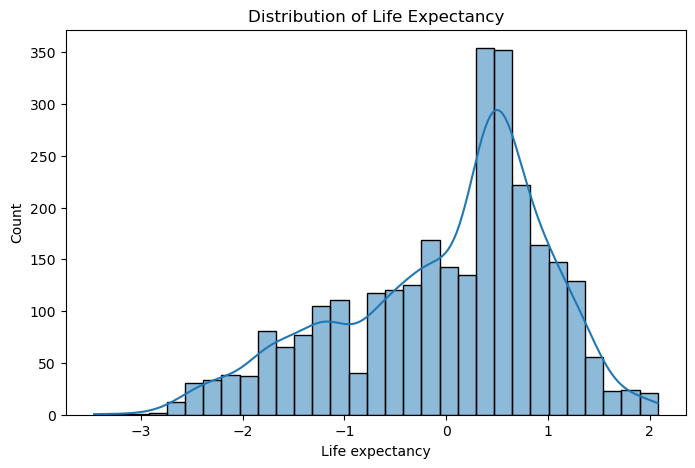

In [113]:
plt.figure(figsize=(8,5))
sns.histplot(df["Life expectancy"], kde=True)
plt.title("Distribution of Life Expectancy")
plt.show()

## CORRELATION MATRIX

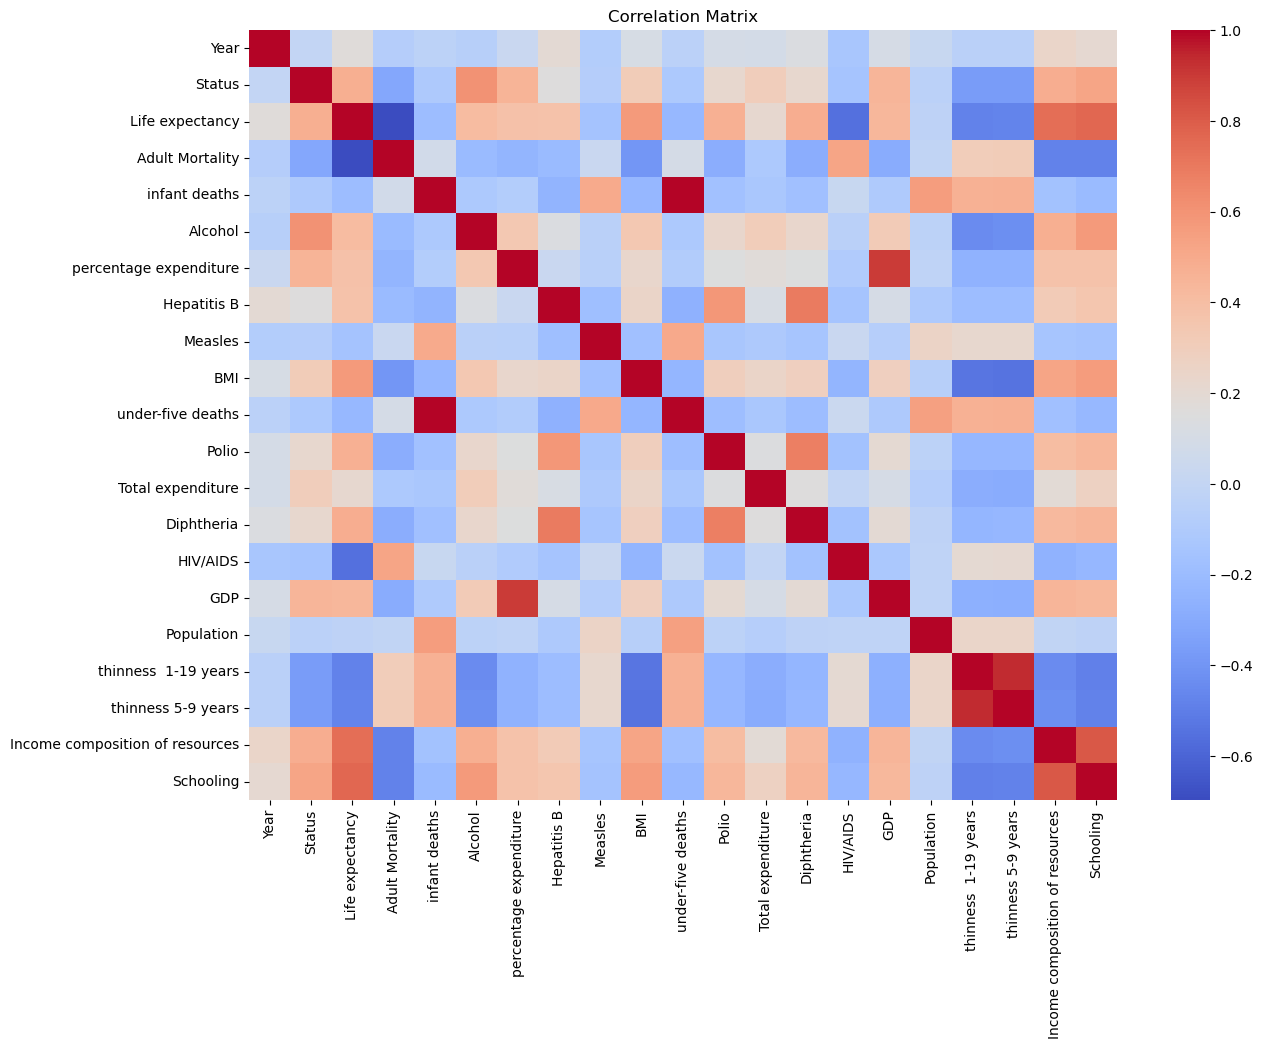

In [114]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),
            cmap='coolwarm',
            annot=False)

plt.title("Correlation Matrix")
plt.show()

In [115]:
corr = df.corr()["Life expectancy"].sort_values(ascending=False)

print(corr)

Life expectancy                    1.000000
Schooling                          0.767789
Income composition of resources    0.741218
BMI                                0.570549
Diphtheria                         0.484297
Status                             0.481376
Polio                              0.470382
GDP                                0.443216
Alcohol                            0.414547
percentage expenditure             0.381160
Hepatitis B                        0.374444
Total expenditure                  0.216871
Year                               0.169590
Population                        -0.027582
Measles                           -0.157428
infant deaths                     -0.196353
under-five deaths                 -0.222293
thinness 5-9 years                -0.475448
thinness  1-19 years              -0.481332
HIV/AIDS                          -0.555889
Adult Mortality                   -0.696561
Name: Life expectancy, dtype: float64


## TOP 10 POSITIVE CORRELATION

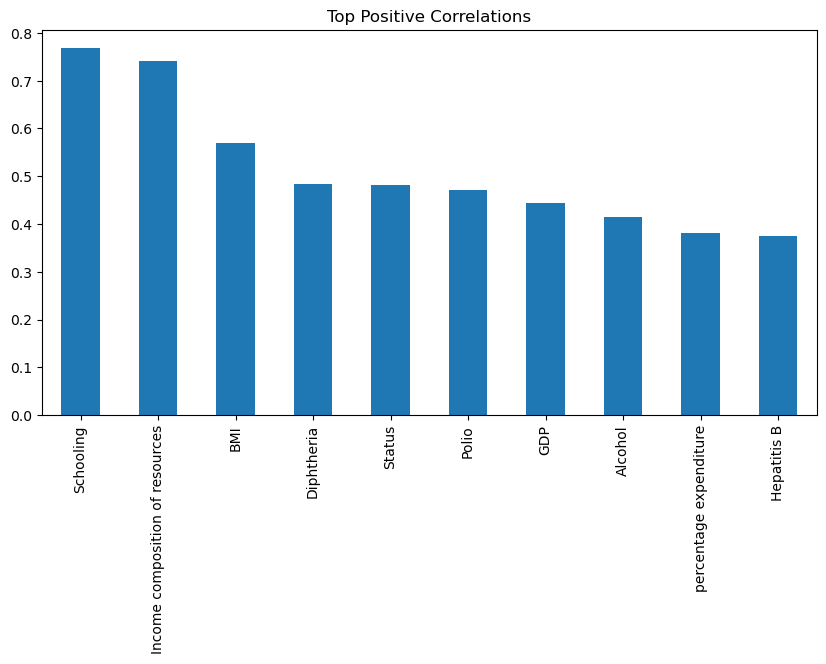

In [116]:
corr.drop("Life expectancy").head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Positive Correlations")
plt.show()


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


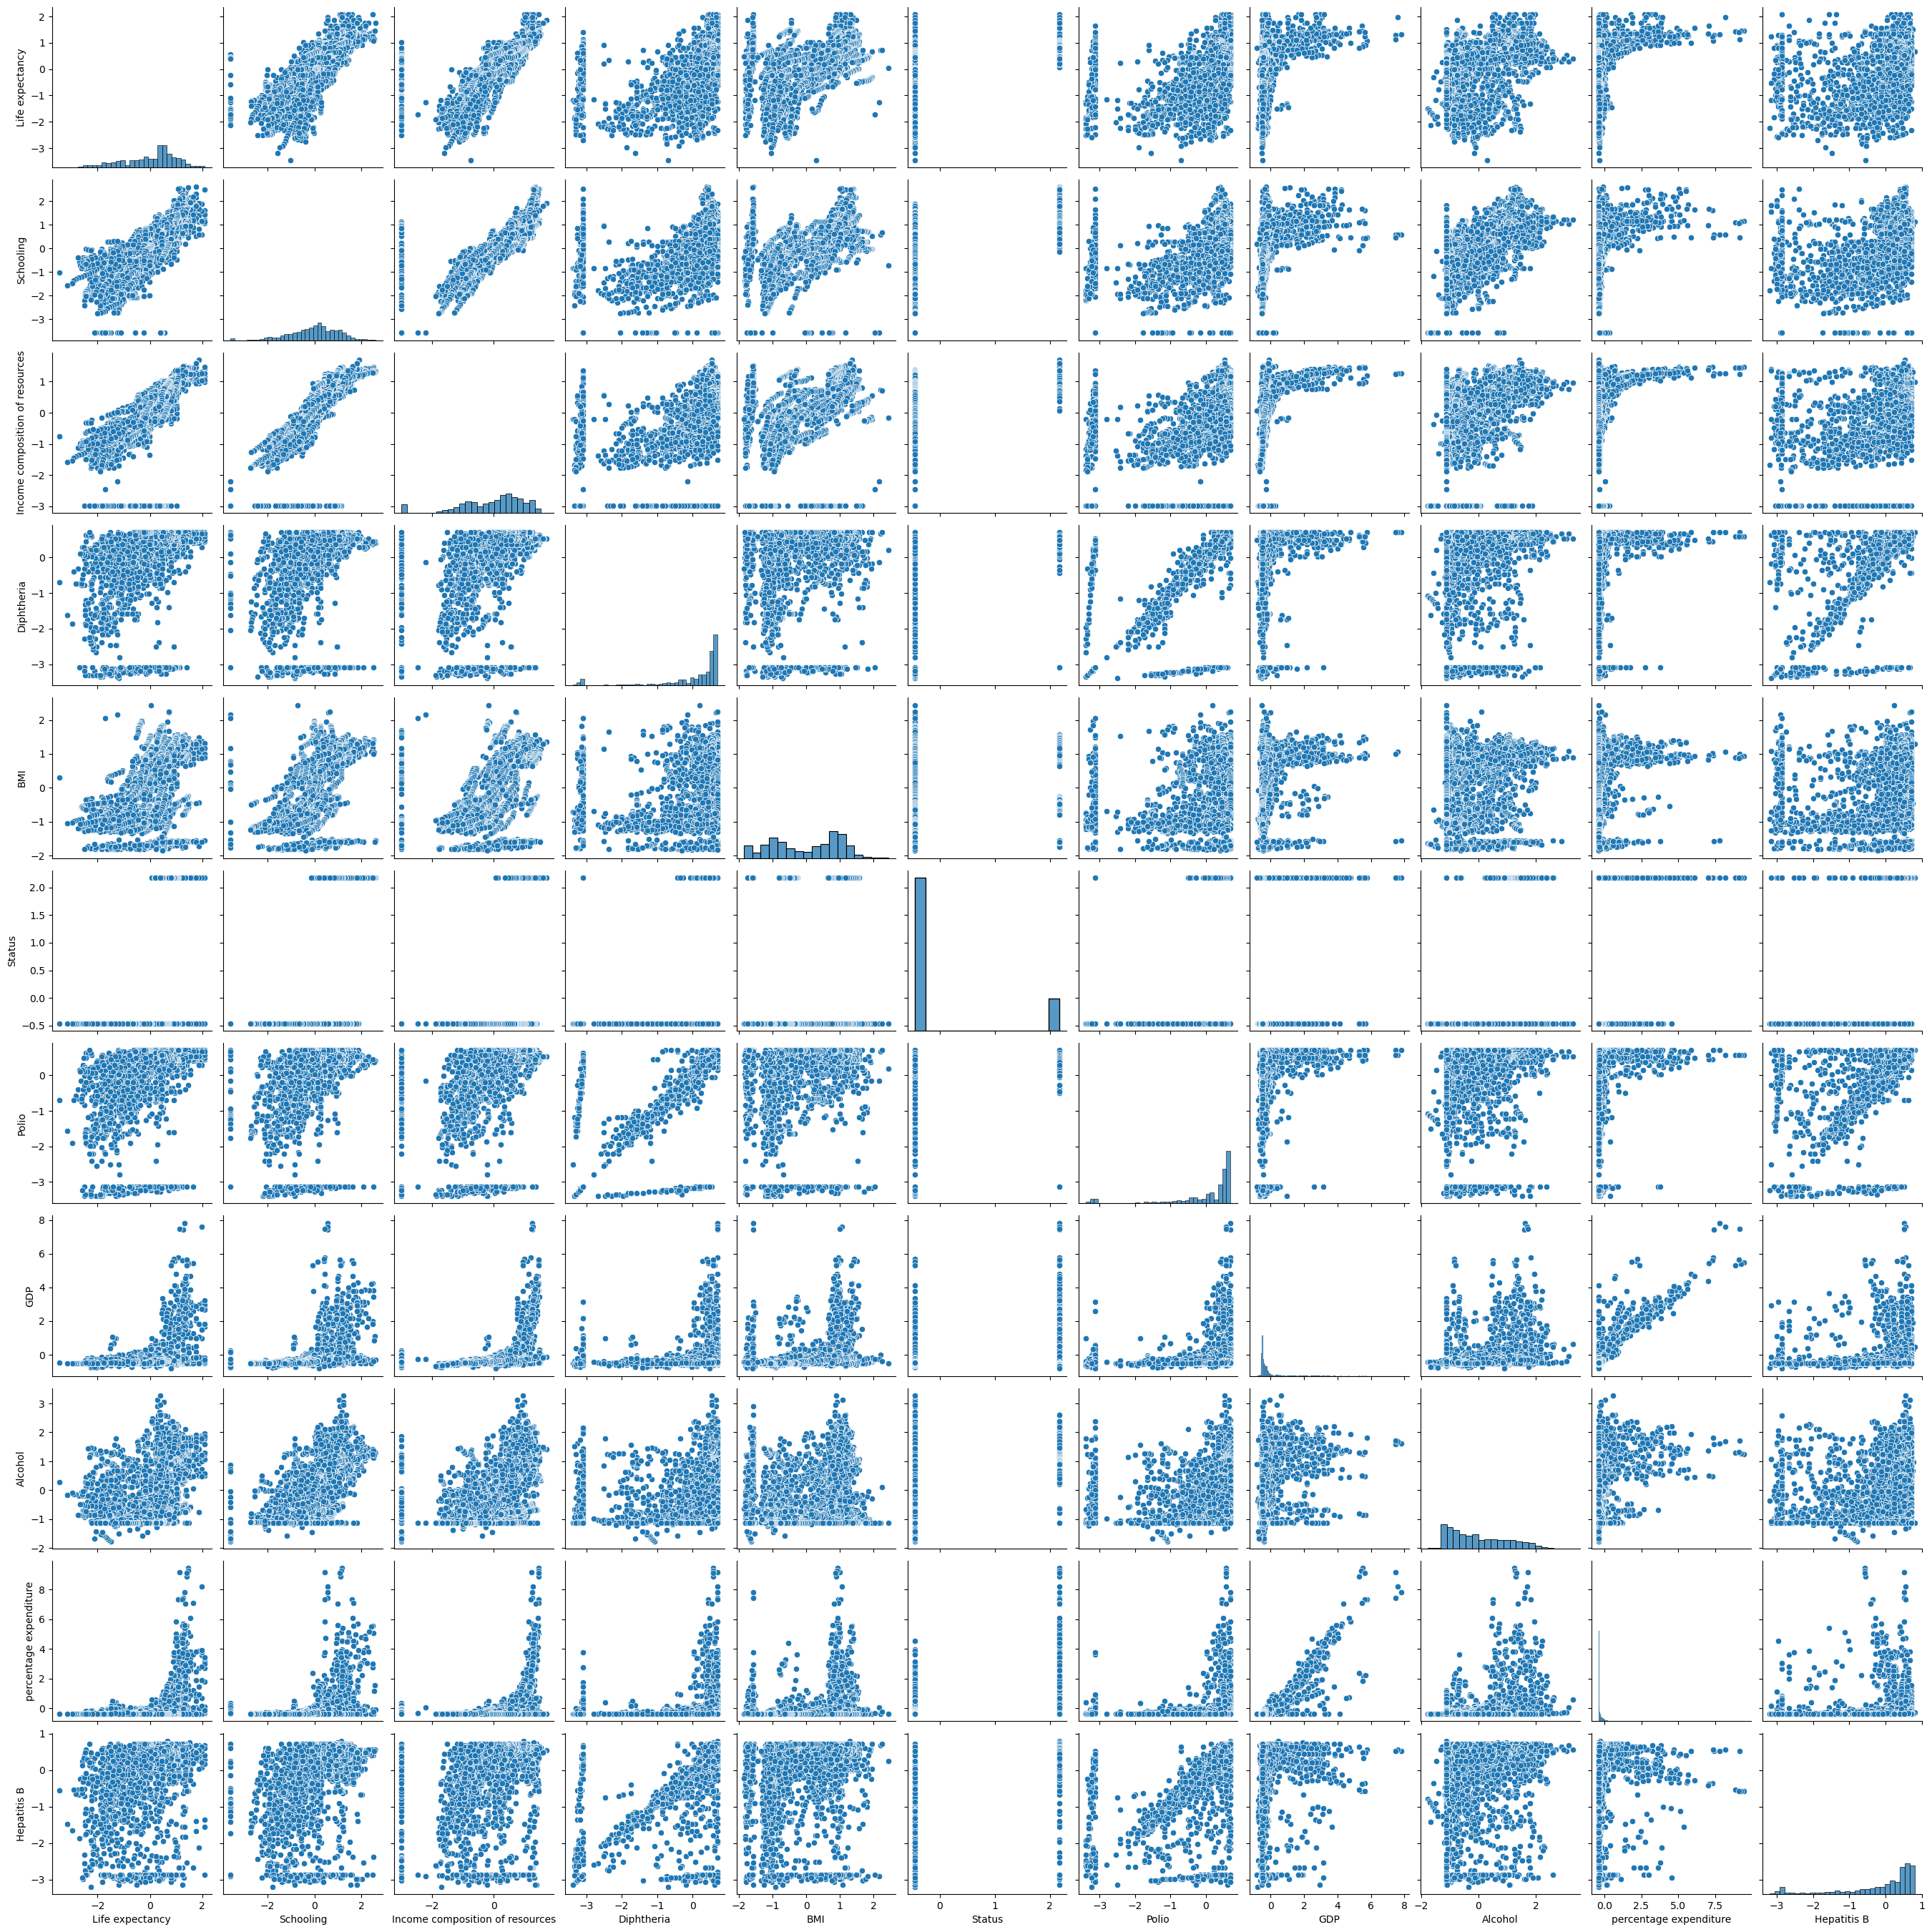

In [117]:
important = [
    "Life expectancy",
    "Schooling",
    "Income composition of resources",
    "Diphtheria",
    "BMI",
    "Status",
    "Polio",
    "GDP",
    "Alcohol",
    "percentage expenditure",
    "Hepatitis B"
]

sns.pairplot(df[important])
plt.show()

## Train-Test Split

In [118]:
X = df.drop("Life expectancy", axis=1)
y = df["Life expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [119]:
X.shape, y.shape

((2938, 20), (2938,))

In [120]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression")
print("R²:", r2_score(y_test, pred_lr))
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))

Linear Regression
R²: 0.8453964458540397
MAE: 0.28359495696511183
RMSE: 0.38539945578033796


In [121]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")
print("R²:", r2_score(y_test, pred_rf))
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

Random Forest
R²: 0.9685465410468276
MAE: 0.11417247452728456
RMSE: 0.17383433728922884


In [122]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_test)

print("Gradient Boosting")
print("R²:", r2_score(y_test, pred_gbr))
print("MAE:", mean_absolute_error(y_test, pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_gbr)))

Gradient Boosting
R²: 0.9571316016080537
MAE: 0.14446913795677183
RMSE: 0.20294109031338253


In [123]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R2": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_gbr)
    ],
    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_gbr)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_gbr))
    ]
})

print(results.sort_values("R2", ascending=False))

               Model        R2       MAE      RMSE
1      Random Forest  0.968547  0.114172  0.173834
2  Gradient Boosting  0.957132  0.144469  0.202941
0  Linear Regression  0.845396  0.283595  0.385399


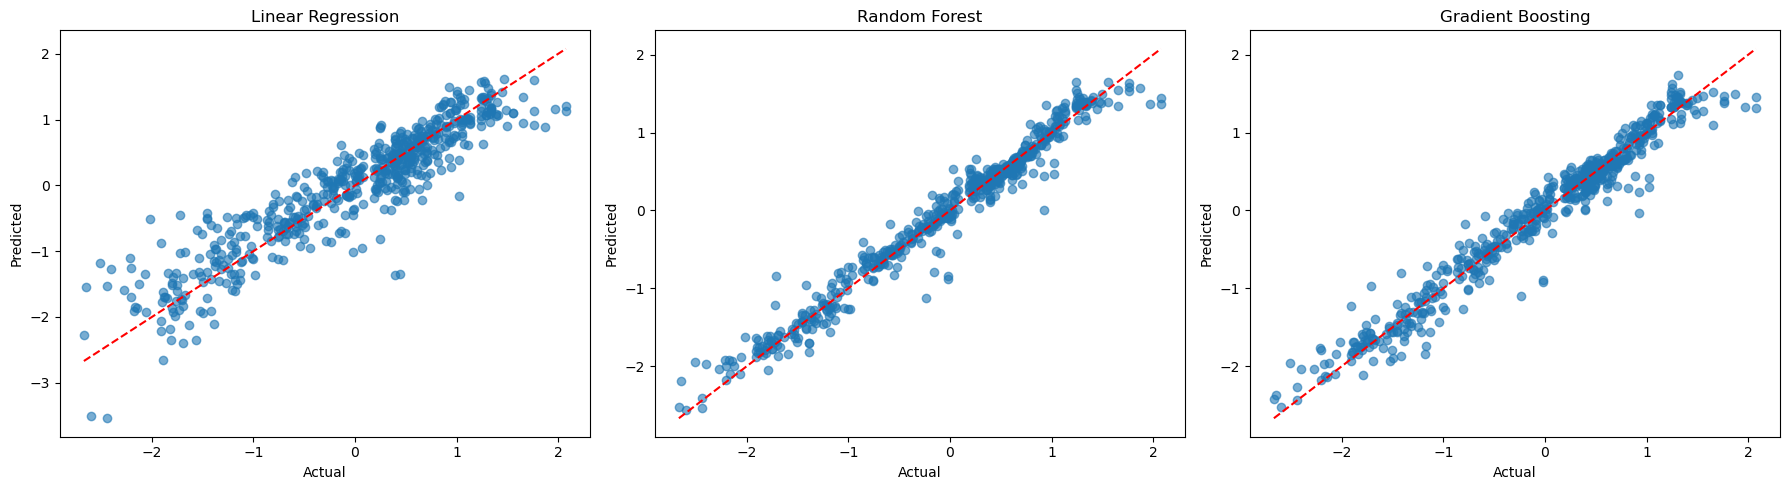

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Linear Regression
axes[0].scatter(y_test, pred_lr, alpha=0.6)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Random Forest
axes[1].scatter(y_test, pred_rf, alpha=0.6)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

# Gradient Boosting
axes[2].scatter(y_test, pred_gbr, alpha=0.6)
axes[2].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[2].set_title("Gradient Boosting")
axes[2].set_xlabel("Actual")
axes[2].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

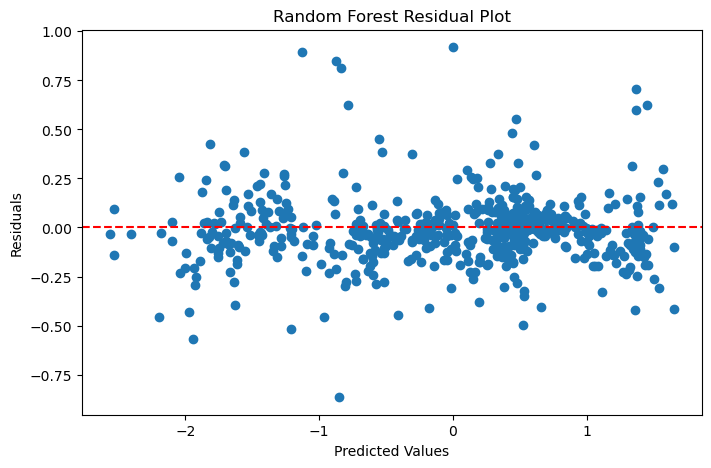

In [125]:
residuals = y_test - pred_rf

plt.figure(figsize=(8,5))
plt.scatter(pred_rf, residuals)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")
plt.show()

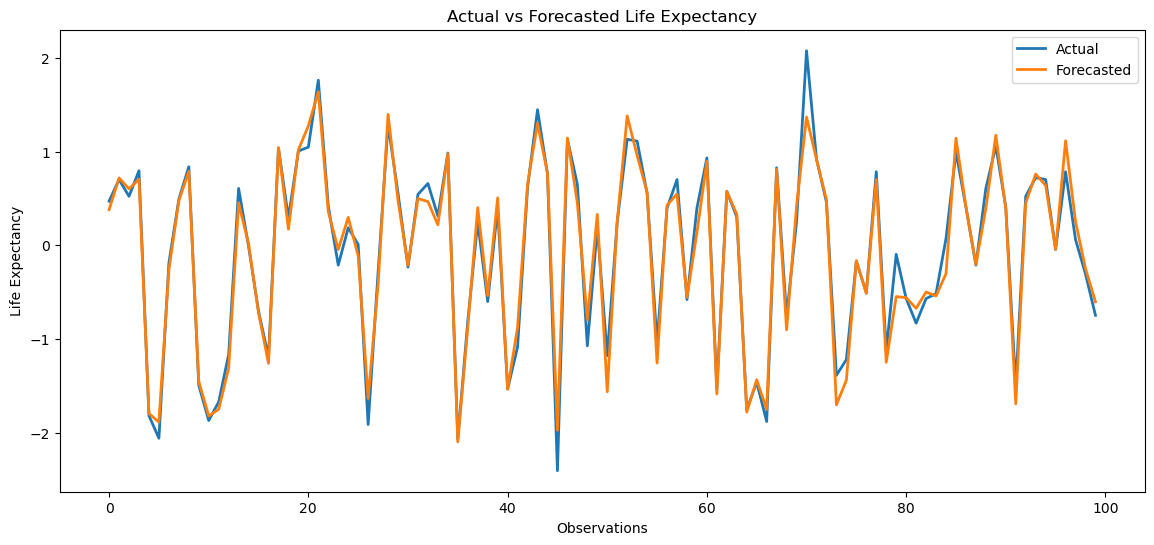

In [126]:
best_model = rf

forecast = best_model.predict(X_test)

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:100],
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast[:100],
    label="Forecasted",
    linewidth=2
)

plt.title("Actual vs Forecasted Life Expectancy")
plt.xlabel("Observations")
plt.ylabel("Life Expectancy")
plt.legend()

plt.show()

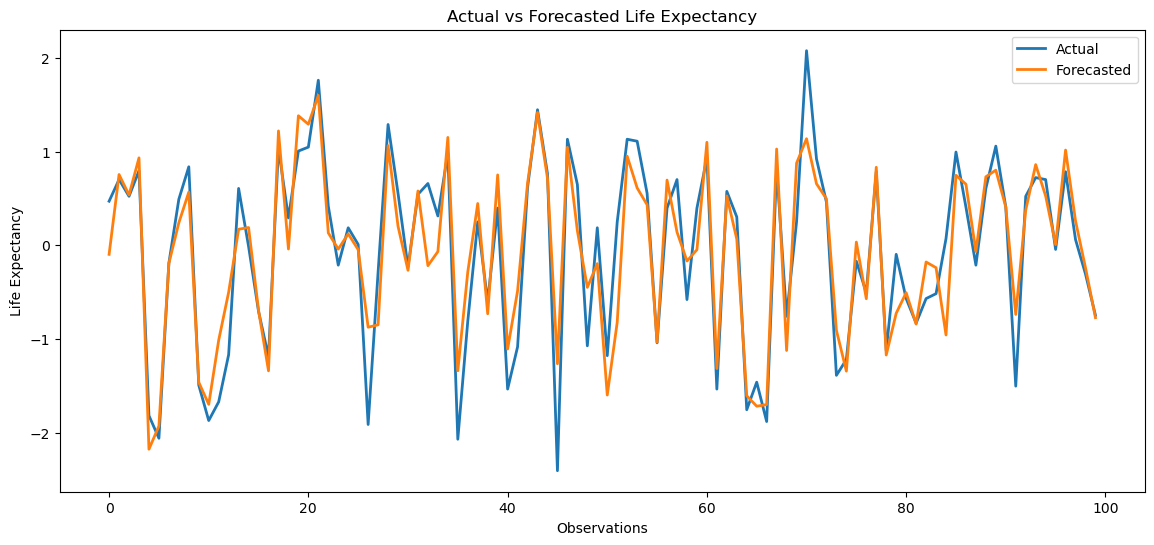

In [127]:
best_model = lr

forecast = best_model.predict(X_test)

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:100],
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast[:100],
    label="Forecasted",
    linewidth=2
)

plt.title("Actual vs Forecasted Life Expectancy")
plt.xlabel("Observations")
plt.ylabel("Life Expectancy")
plt.legend()

plt.show()

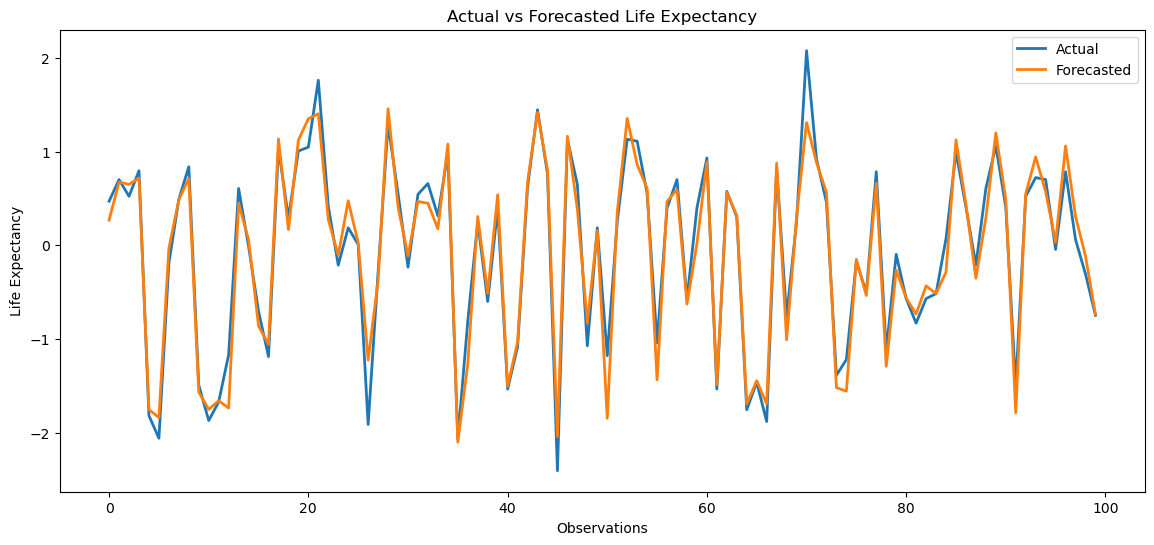

In [128]:
best_model = gbr

forecast = best_model.predict(X_test)

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:100],
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast[:100],
    label="Forecasted",
    linewidth=2
)

plt.title("Actual vs Forecasted Life Expectancy")
plt.xlabel("Observations")
plt.ylabel("Life Expectancy")
plt.legend()

plt.show()

# Policy Recommendations

### Scale Immunization Infrastructure: Prioritize high-coverage vaccination campaigns for foundational preventative measures—specifically Hepatitis B, Polio, and Diphtheria—to directly mitigate childhood mortality and lift baseline national life expectancies.

### Optimize Healthcare Expenditure Allocation: Ensure that increases in total government health expenditure translate into frontline clinical capacity, primary care access, and preventative screening programs rather than administrative overhead.

### Targeted HIV/AIDS and Infectious Disease Containment: Maintain aggressive screening, antiretroviral treatment distribution, and public awareness campaigns in high-prevalence regions, as infectious disease burdens exert an immediate, disproportionate drag on longevity.

### Expand Educational Access: Invest heavily in long-term educational infrastructure and schooling years, recognizing that adult literacy and secondary educational attainment act as powerful structural catalysts for informed health choices and elevated socio-economic status.

# Conclusion

### Achieving sustainable improvements in global population health requires moving beyond generalized economic growth toward targeted, multidimensional public health strategies. While national wealth (GDP) and public spending provide the financial foundation for healthcare systems, regression modeling demonstrates that the composition of that spending—specifically toward widespread immunization coverage, robust disease control, and education—dictates long-term longevity gains. Governments and international health organizations can maximize their epidemiological impact by redirecting resources into preventative medicine and systemic disease mitigation, ultimately bridging global health divides and securing a higher quality of life across populations.